# Direct S3 Access AVIRIS-NG Version 2 NetCDF-4 File

In [1]:
# import modules
import s3fs
import xarray as xr
import hvplot.xarray
import matplotlib.pyplot as plt
import holoviews as hv
hvplot.extension('bokeh')

In [2]:
s3 = s3fs.S3FileSystem(anon=False)

In [3]:
s3.ls('bioscape-data/AVNG_V2/ang20231022t094938/ang20231022t094938_003')

['bioscape-data/AVNG_V2/ang20231022t094938/ang20231022t094938_003/ang20231022t094938_003_L1B_ORT_fb78102f_OBS.json',
 'bioscape-data/AVNG_V2/ang20231022t094938/ang20231022t094938_003/ang20231022t094938_003_L1B_ORT_fb78102f_OBS.nc',
 'bioscape-data/AVNG_V2/ang20231022t094938/ang20231022t094938_003/ang20231022t094938_003_L1B_RDN_4a3c998e_RDN.json',
 'bioscape-data/AVNG_V2/ang20231022t094938/ang20231022t094938_003/ang20231022t094938_003_L1B_RDN_4a3c998e_RDN.nc',
 'bioscape-data/AVNG_V2/ang20231022t094938/ang20231022t094938_003/ang20231022t094938_003_L2A_OE_0b4f48b4_RFL_ORT.json',
 'bioscape-data/AVNG_V2/ang20231022t094938/ang20231022t094938_003/ang20231022t094938_003_L2A_OE_0b4f48b4_RFL_ORT.nc']

In [4]:
nc_file = 'bioscape-data/AVNG_V2/ang20231022t094938/ang20231022t094938_003/ang20231022t094938_003_L2A_OE_0b4f48b4_RFL_ORT.nc'
fh = s3.open(nc_file, mode='rb')
dt = xr.open_datatree(fh, engine='h5netcdf')  
dt

<xarray.DataTree>
Group: /
│   Dimensions:              (easting: 820, northing: 1854)
│   Coordinates:
│     * easting              (easting) float64 7kB 3.106e+05 3.106e+05 ... 3.157e+05
│     * northing             (northing) float64 15kB 6.238e+06 ... 6.226e+06
│   Data variables:
│       transverse_mercator  |S1 1B ...
│   Attributes: (12/23)
│       Conventions:                       CF-1.6
│       date_created:                      2024-11-25T23:11:51Z
│       summary:                           The Airborne Visible / Infrared Imagin...
│       keywords:                          Imaging Spectroscopy, AVIRIS, AVIRIS-NG
│       sensor:                            Airborne Visible / Infrared Imaging Sp...
│       instrument:                        AVIRIS-NG
│       ...                                ...
│       ncei_template_version:             NCEI_NetCDF_Grid_Template_v2.0
│       title:                             AVIRIS-NG L2A Surface reflectance (fli...
│       processing_level:                  L2A
│       time_coverage_start:               2023-10-22T09:53:03Z
│       time_coverage_end:                 2023-10-22T09:53:03Z
│       product_version:                   1
├── Group: /reflectance
│       Dimensions:      (wavelength: 425, northing: 1854, easting: 820)
│       Coordinates:
│         * wavelength   (wavelength) float32 2kB 377.2 382.2 ... 2.496e+03 2.501e+03
│       Data variables:
│           fwhm         (wavelength) float32 2kB ...
│           reflectance  (wavelength, northing, easting) float32 3GB ...
├── Group: /aerosol_optical_thickness
│       Dimensions:                    (northing: 1854, easting: 820)
│       Data variables:
│           aerosol_optical_thickness  (northing, easting) float32 6MB ...
└── Group: /water_vapor
        Dimensions:      (northing: 1854, easting: 820)
        Data variables:
            water_vapor  (northing, easting) float32 6MB ...

In [5]:
# plot true color image
h = dt.reflectance.to_dataset().sel(wavelength=[660, 570, 480], 
                                    method="nearest").reflectance.hvplot.rgb('easting', 'northing',
                                                                             rasterize=True,data_aspect=1,
                                                                             bands='wavelength',frame_width=400)
h

:DynamicMap   []
   :RGB   [easting,northing]   (R,G,B)

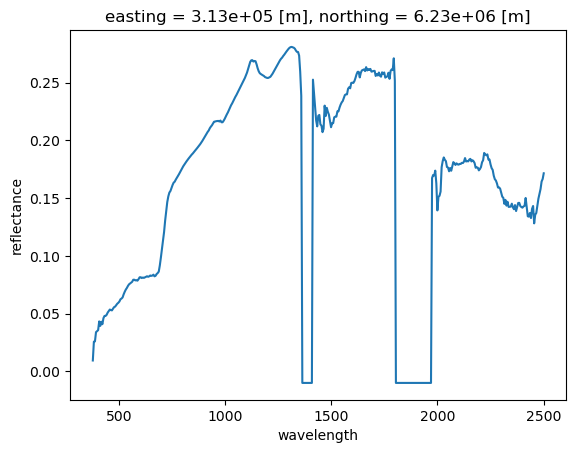

In [6]:
# plot spectra from a pixel
dt.reflectance.to_dataset().sel(easting=313000, northing=6230000, 
                                        method="nearest").reflectance.plot.line()
plt.xlabel("wavelength")
plt.ylabel("reflectance")
plt.show()

In [7]:
# close file
fh.close()